# Restaurant Revenue Prediction — 03 Model Building

We train **7 regressors** and compare them, with an honest focus on the small-data reality: with 110 training rows and ~40 features, **cross-validation R² is far more trustworthy than a single test split**. We also tune the best model and compare it to the naive 'predict the mean' baseline. All numbers are produced by running the code.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import utils

cleaned = pd.read_csv('data/train_cleaned.csv')
y = cleaned['revenue']
X = cleaned.drop(columns='revenue')
print('X:', X.shape)

X: (137, 41)


## 1. Train/test split + scaling

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
X_all_s = scaler.transform(X)
print('train:', X_train_s.shape, '| test:', X_test_s.shape)

train: (109, 41) | test: (28, 41)


## 2. Compare 7 regressors

`test_*` are from the held-out 20% split; `cv_r2_*` are 5-fold cross-validation on the full data. Rows are sorted by CV R² (the reliable metric).

In [3]:
results = utils.compare_models(utils.get_models(), X_train_s, X_test_s, y_train, y_test,
                               X_all=X_all_s, y_all=y, cv=5)
results

,model,test_r2,test_rmse,test_mae,cv_r2_mean,cv_r2_std
0,KNN,0.0270,3450111.7,2068447.6,-0.0964,0.2467
1,Random Forest,0.0562,3397912.0,1874699.5,-0.1200,0.3317
2,Ridge,-0.0530,3589143.7,2323350.7,-0.3236,0.4582
3,Gradient Boosting,0.0981,3321798.3,1930440.2,-0.6839,0.8962
4,Decision Tree,-0.1263,3711974.7,1813717.6,-0.9342,0.8466
5,Lasso,-0.5464,4349499.8,2941801.1,-1.7874,1.5445
6,Linear Regression,-0.5776,4393210.9,2973798.4,-1.9336,1.6258


## 3. The honest picture: R² is near zero

Both test and CV R² hover around 0 (and go negative for the linear models, which **overfit** badly with ~40 features on 110 rows). A negative R² means the model does worse than simply predicting the mean revenue. Tree ensembles are the least bad.

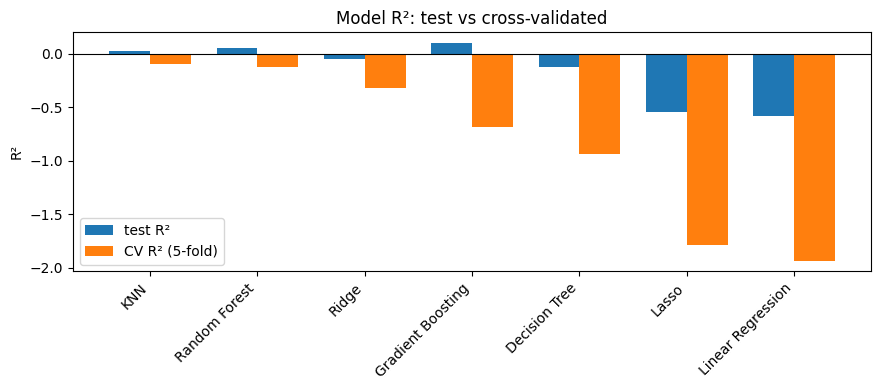

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(results)); w = 0.38
ax.bar(x - w/2, results['test_r2'], w, label='test R²')
ax.bar(x + w/2, results['cv_r2_mean'], w, label='CV R² (5-fold)')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(results['model'], rotation=45, ha='right')
ax.set_ylabel('R²'); ax.set_title('Model R²: test vs cross-validated'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Predicted vs actual (Random Forest)

Random Forest is among the most stable models. The scatter shows predictions cluster near the mean — the model captures little of the revenue variation.

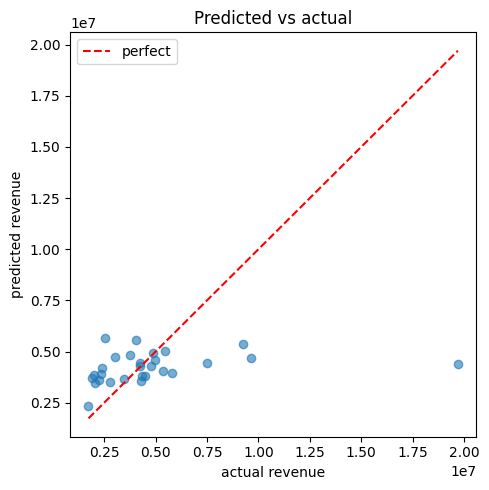

In [5]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train_s, y_train)
fig, ax = plt.subplots(figsize=(5, 5))
utils.plot_pred_vs_actual(rf, X_test_s, y_test, ax=ax); plt.tight_layout(); plt.show()

## 5. What little signal exists — feature importance

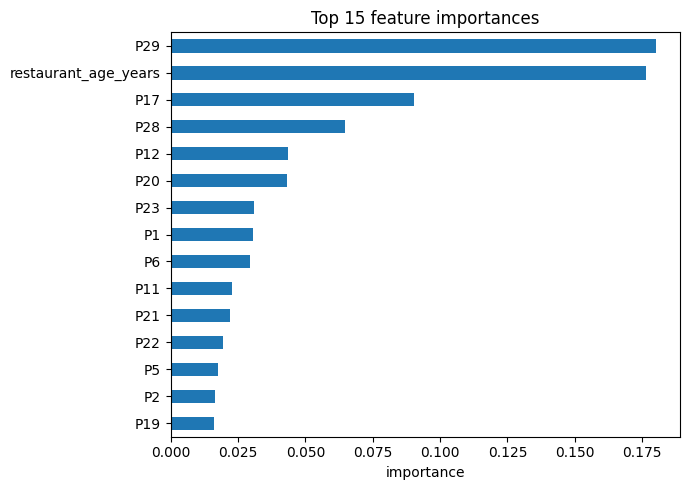

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
utils.plot_feature_importance(rf, X.columns, top_n=15, ax=ax); plt.tight_layout(); plt.show()

## 6. Tune Random Forest & compare to the mean baseline

We grid-search shallow forests (which resist overfitting) and check whether the tuned model beats simply predicting the training-mean revenue on the test set.

In [7]:
grid = {'n_estimators': [100, 300], 'max_depth': [2, 3, 4, None], 'min_samples_leaf': [1, 3, 5]}
gs = GridSearchCV(RandomForestRegressor(random_state=42), grid, cv=5, scoring='r2', n_jobs=-1)
gs.fit(X_all_s, y)
print('best params :', gs.best_params_)
print('best CV R²  : %.4f' % gs.best_score_)

best = gs.best_estimator_
best.fit(X_train_s, y_train)
pred = best.predict(X_test_s)
tuned_rmse = np.sqrt(mean_squared_error(y_test, pred))
base_rmse = np.sqrt(mean_squared_error(y_test, np.full(len(y_test), y_train.mean())))
print('tuned test R²   : %.4f' % r2_score(y_test, pred))
print(f'tuned test RMSE : {tuned_rmse:,.0f}')
print(f'baseline RMSE   : {base_rmse:,.0f}  (predict training mean)')
print('improvement over baseline: %.1f%%' % (100 * (base_rmse - tuned_rmse) / base_rmse))

best params : {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
best CV R²  : -0.0243
tuned test R²   : 0.0423
tuned test RMSE : 3,422,907
baseline RMSE   : 3,518,220  (predict training mean)
improvement over baseline: 2.7%


## 7. Prediction example

In [8]:
sample = X_test.iloc[[0]]
sample_s = scaler.transform(sample)
print(f'predicted revenue: {best.predict(sample_s)[0]:,.0f}')
print(f'actual revenue   : {y_test.iloc[0]:,.0f}')

predicted revenue: 3,581,747
actual revenue   : 2,792,031


## 8. Final summary & takeaways

- **Revenue is only weakly predictable from these features at n=137.** The best cross-validated R² is ≈ **−0.02** (tuned Random Forest) — essentially the mean baseline. On the held-out split the tuned RF reaches R² ≈ **0.04**, RMSE ≈ **\$3.42M** vs the mean-baseline RMSE of ≈ **\$3.52M** — a real but small **~3% improvement**.
- **Linear models overfit catastrophically** (R² strongly negative) because there are ~40 features for 110 training rows. Regularised / shallow-ensemble models are the only sensible choice here.
- **The useful signal is concentrated** in restaurant **age** and **City Group**, with the obfuscated P-features contributing weak, diffuse information.
- **The real lesson is methodological**: with tiny n and large p, a single test split is misleading (it looked positive while CV was negative). Always cross-validate and compare against a naive baseline before claiming a model 'works'.
- To do meaningfully better you would need more rows, de-anonymised features, or external data (location footfall, competition, marketing spend).